# Implementation tests

In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

## Risk factor simulation

In [25]:


# Example inputs
num_risk_factors = 3
initial_spot_values = [100.0, 60.0, 140.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.10, 0.25, 0.40]
correl_matrix = [
    [1.0, 0.80, 0.10],
    [0.80, 1.0, -0.5],
    [0.10, -0.5, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,10,50)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps
)

paths = simulator.simulate_paths(num_sims=num_sims)


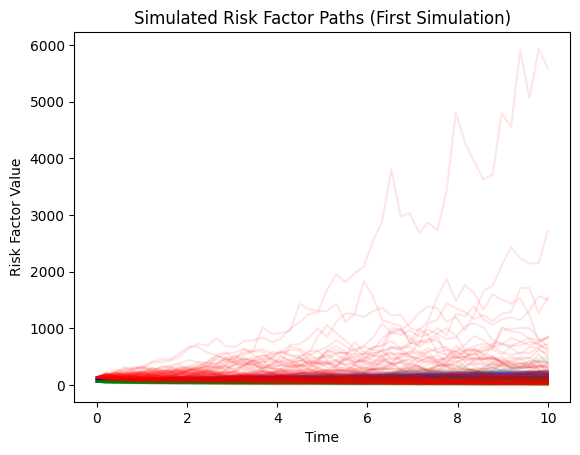

In [26]:
plt.plot(time_steps, paths[:100, :, 0].numpy().T, color='blue', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 1].numpy().T, color='green', alpha=0.1)
plt.plot(time_steps, paths[:100, :, 2].numpy().T, color='red', alpha=0.1)
plt.title("Simulated Risk Factor Paths (First Simulation)")
plt.xlabel("Time")
plt.ylabel("Risk Factor Value")
plt.show()

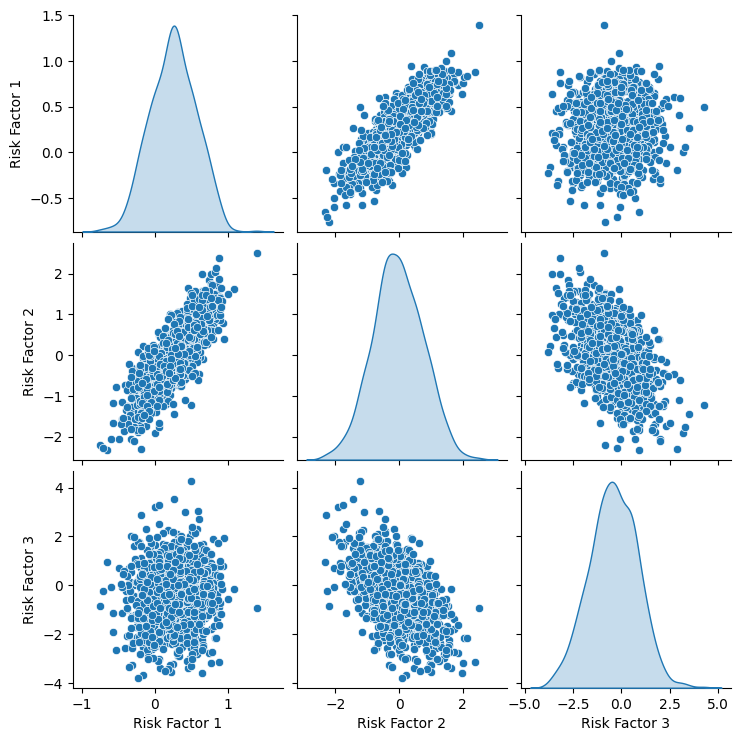

In [4]:
sns.pairplot(
    pd.DataFrame(np.log(paths[:,-1,:].numpy()/paths[:,0,:].numpy()), columns=[f"Risk Factor {i+1}" for i in range(num_risk_factors)]),
    diag_kind="kde")

## Volatility and correlation test

In [5]:
time_steps = [0.0, 0.5, 1.0, 2.5, 5.0, 7.5, 10.0, 15.0, 30.0]

corr_matrix = [[1.0, 0.80, 0.10],
               [0.80, 1.0, -0.5],
                [0.10, -0.5, 1.0]]

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)

paths = simulator.simulate_paths(num_sims=30000)

for i in range(len(time_steps)-1):

    returns = np.log(paths[:,i+1,:].numpy()/paths[:,i,:].numpy())

    print("Volatilities at time step ", time_steps[i], ":", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step ", time_steps[i], ":")
    print(np.corrcoef(returns.T))
    



Volatilities at time step  0.0 : [0.09999046 0.25077065 0.40089313]
Correl matrix at time step  0.0 :
[[ 1.          0.80021117  0.09525366]
 [ 0.80021117  1.         -0.50392302]
 [ 0.09525366 -0.50392302  1.        ]]
Volatilities at time step  0.5 : [0.09972348 0.24912916 0.40194738]
Correl matrix at time step  0.5 :
[[ 1.          0.79700202  0.10562627]
 [ 0.79700202  1.         -0.4993202 ]
 [ 0.10562627 -0.4993202   1.        ]]
Volatilities at time step  1.0 : [0.09983892 0.25078389 0.39977872]
Correl matrix at time step  1.0 :
[[ 1.          0.8014818   0.09044797]
 [ 0.8014818   1.         -0.50657061]
 [ 0.09044797 -0.50657061  1.        ]]
Volatilities at time step  2.5 : [0.09972788 0.24999723 0.40112448]
Correl matrix at time step  2.5 :
[[ 1.          0.79777521  0.09836505]
 [ 0.79777521  1.         -0.50479001]
 [ 0.09836505 -0.50479001  1.        ]]
Volatilities at time step  5.0 : [0.09988513 0.24941648 0.40232274]
Correl matrix at time step  5.0 :
[[ 1.          0.7

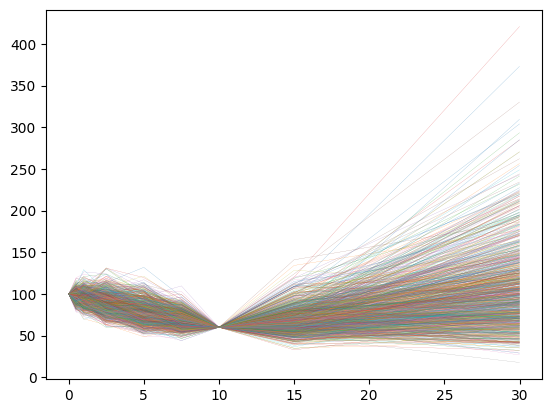

In [18]:
spot_t = [60,140,100]



brown_bridge_paths = simulator.simulate_paths_with_bridge(num_sims = 1000,
        pivot_step_idx = 6,
        spot_at_pivot= spot_t)


plt.plot(time_steps, brown_bridge_paths[:,:,0].T.detach(), linewidth = 0.1);



In [7]:

for i in range(len(time_steps)-1):

    returns = np.log(brown_bridge_paths[:,i+1,:].numpy()/brown_bridge_paths[:,i,:].numpy())

    print("Volatilities at time step ", time_steps[i], ":", np.std(returns, axis=0)/np.sqrt(time_steps[i+1]-time_steps[i]))
    print("Correl matrix at time step ", time_steps[i], ":")
    print(np.corrcoef(returns.T))

Volatilities at time step  0.0 : [0.09577429 0.24222588 0.38945662]
Correl matrix at time step  0.0 :
[[ 1.          0.79300097  0.089715  ]
 [ 0.79300097  1.         -0.5180159 ]
 [ 0.089715   -0.5180159   1.        ]]
Volatilities at time step  0.5 : [0.09868479 0.24291249 0.38961346]
Correl matrix at time step  0.5 :
[[ 1.          0.79586426  0.1362617 ]
 [ 0.79586426  1.         -0.47462744]
 [ 0.1362617  -0.47462744  1.        ]]
Volatilities at time step  1.0 : [0.09009904 0.22753478 0.36768742]
Correl matrix at time step  1.0 :
[[ 1.          0.79738688  0.08939123]
 [ 0.79738688  1.         -0.51387052]
 [ 0.08939123 -0.51387052  1.        ]]
Volatilities at time step  2.5 : [0.08444498 0.21412152 0.33625772]
Correl matrix at time step  2.5 :
[[ 1.          0.80830965  0.06919269]
 [ 0.80830965  1.         -0.51442964]
 [ 0.06919269 -0.51442964  1.        ]]
Volatilities at time step  5.0 : [0.08438698 0.21073828 0.32942067]
Correl matrix at time step  5.0 :
[[ 1.          0.8

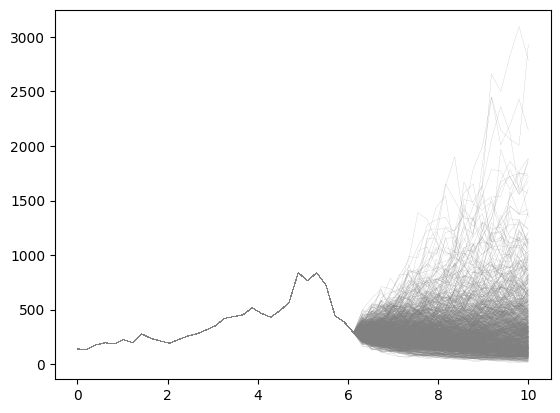

In [74]:
time_steps = np.linspace(0,10,50)


simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps)



upto_point_paths = simulator.simulate_same_path_up_do_date(num_sims = 1000,
        pivot_step_idx = 30)



plt.plot(time_steps, upto_point_paths[:,:,2].T.detach(), linewidth = 0.1, color = 'grey');